In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import itertools
import time


def bvn(x, y, xmean, ymean, cov=np.array([[1,0],[0,1]])): 
    '''
    calculates bivariate density at x,y given means and covariance matrix
    x,y are coordinates, default covariance is variance 1 for both and no covariance (independent x and y)
    '''
    xy = np.array([[x],[y]])
    mu = np.array([[xmean],[ymean]])
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    denom = np.sqrt(((2 * np.pi)**2) * det)
    num = np.e ** (-1/2 * (xy - mu).T @ inv @ (xy - mu))
    return (num/denom)[0][0] # index into a np.array([[v]]) to extract the value

def init_background_density(board, n, rng):
    '''
    board = 2d grid
    uses bvn to stack n random gaussian distributions
    visualizes distribution at end via matplotlib imshow
    potential issues: can have lots of them stacked on top of each other
    '''
    board = np.copy(board)
    
    for dist in range(n):
        
        # generate a random center for the gaussian
        xmean = rng.integers(0, high=len(board[0])) # elements per row (number of columns)
        ymean = rng.integers(0, high=len(board)) # number of rows
        # uses circular bvns, x and y have same variance (can be changed)
        var = rng.integers(len(board)//4, high=len(board)//2)
        
        for (x,y), v in np.ndenumerate(board):
            board[x,y] += bvn(x,y, xmean, ymean, cov=np.array([[var,0],[0,var]]))

    return board

def get_targets(board, threshold):
    '''
    returns target locations if density is above a certain threshold
    may be useless
    '''
    targets = np.array([])
    for (x,y), v in np.ndenumerate(board):
        if v >= threshold:
            targets = np.append(targets, [x,y])
    return targets

def sample_agents(board, n, rng):
    '''
    samples n agents from a board, assumes that not all values are zero
    uniform random sampling across board (does not weight based on background density...)
    can initiate multiple agents in the same grid space
    '''
    agents = np.array([])
    violent_agent_count = 0
    x = rng.integers(0, high=len(board[0]), size=n) # elements per row (number of columns)
    y = rng.integers(0, high=len(board), size=n) # number of rows
    for i in range(n):
        a = Agent(x[i],y[i], i)
        # die roll
        if rng.integers(0, 10) >= 8:
            a.violent_tendencies = True # 0.2 chance that they are violent
            if rng.integers(0,10) > 9:
                a.possesses_weapon = True # 0 chance that a violent agent already possesses a weapon
                violent_agent_count += 1
        agents = np.append(agents, a)
    return agents

def move_agent(board, agent, rng):
    '''
    moves agent in a random walk by one space
    '''
    x = rng.integers(max(0, agent.x-1), high=min(len(board[0])-1, agent.x+1)+1)
    y = rng.integers(max(0, agent.y-1), high=min(len(board)-1, agent.y+1)+1)

    agent.x = x
    agent.y = y
    
    return board, agent

def agent_go_home(board, agent):
    '''
    reset agent position to their home coordinates
    '''
    agent.x = agent.home_coordinates[0]
    agent.y = agent.home_coordinates[1]
    
    return board, agent

def agent_initiate_event(board, agent, threshold):
    x = agent.x
    y = agent.y
    return (board[x,y] >= threshold) and agent.violent_tendencies and agent.possesses_weapon

# this could be represented as an array instead of a class: e.g np.array([x,y,0,0,x,y])
class Agent():
    def __init__(self, x, y, idn):
        self.x = x
        self.y = y
        self.violent_tendencies = False
        self.possesses_weapon = False
        self.home_coordinates = np.array([x,y])   
        self.id = idn


def initiate_weapon_retailers(board, n, rng):
    '''
    most weapons seem to be bought, so let's add some different locations where agents can purchase them
    randomly generates n unique locations and returns them stored in a dictionary that's x:[y] pairs
    '''
    
    ax = range(max(len(board),len(board[0])))
    points = []
    
    for pair in itertools.permutations(ax,2):
        if pair[0] < min(len(board), len(board[0])): # throw out points that are out of range for a rectangular board
            points.append(pair)
    # above itertools function doesn't include diagonal elements (e.g 0,0, for some reason. idk) so we will add them manually
    for i in range(min(len(board), len(board[0]))):
        points.append((i,i))
        
    # points is a list of tuples
    points = rng.permutation(points)
    
    #plt.scatter([x[0] for x in points], [y[1] for y in points]) for debugging purposes
    # store in dictionary for faster accessing later
    locs = {}
    for i in range(n):
        if points[i][0] in locs:
            locs[points[i][0]].append(points[i][1])
        else:
            locs[points[i][0]] = [points[i][1]]
    return locs


def agent_buy_weapon(board, agent, retailers, rng):
    '''
    if agent is at a retailer location, roll die to have them buy or not (?)
    '''
    if agent.possesses_weapon == True:
        return # nothing to do
    
    if agent.x in retailers and agent.y in retailers[agent.x]: # current agent location is the location of a retailer
        # roll a die (?)
        v = rng.integers(0,10)
        if v >= 8: # i picked this number based on vibes, 20% chance they buy
            agent.possesses_weapon = True
        

In [2]:
# plotting conveniences

def plot_timesteps(output, num_iter):
    '''
    plot distribution of times of events given a list of dictionaries
    '''
    times = [i["timestep"] for i in output if i]
    plt.figure(figsize=(10,4))
    plt.hist(times, bins=range(0, num_iter + 15, 15), edgecolor='black', linewidth=1.2)
    stats = {"mean": np.mean(times), "median": np.median(times)}
    print(stats)
    return stats
    

In [3]:
# sim

rng = np.random.default_rng() # set seed for reproducibility

board = np.zeros((50,50))
board = init_background_density(board, 40, rng)

b = deepcopy(board)

agents = sample_agents(board, 250, rng)

num_retailers = max(5, len(board) * len(board[0]) // 100)
retailers = initiate_weapon_retailers(board, num_retailers, rng)

events = []
t = 500
for i in range(t):
    new_agents = np.array([])
    for a in agents:
        move_agent(board, a, rng)
        agent_buy_weapon(board, a, retailers, rng)
        if agent_initiate_event(board, a, np.max(b)/2):
            events.append({"x":a.x, "y":a.y, "bkg_density":board[a.x,a.y], "timestep": i, "agent":a.id})
        else:
            new_agents = np.append(new_agents, a)
    agents = new_agents # to ensure each agent can only initiate one event
    if t % 100 == 0:
        agent_go_home(board, a)
events[0]

{'x': 9,
 'y': 46,
 'bkg_density': 0.025951789859708807,
 'timestep': 69,
 'agent': 68}

In [4]:
def run_abm(board_size=(50,50), 
            num_iter=500, 
            num_agents=250, 
            num_retailers=10,
            num_gaussians=40,
            threshold=0.03,
            seed=None):
    
    '''
    run the abm simulation
    board_size: a tuple or list (x,y) dimensions
    num_iter: number of iterations
    seed: for the rng 
    '''
    
    if not seed:
        rng = np.random.default_rng() 
    else:
        rng = np.random.default_rng(seed=seed)
        
    board = np.zeros((board_size[0],board_size[1]))
    board = init_background_density(board, num_gaussians, rng)
    b = deepcopy(board)
    agents = sample_agents(board, num_agents, rng)
    
    retailers = initiate_weapon_retailers(board, num_retailers, rng)
    
    events = []
    
    for i in range(num_iter):
        new_agents = np.array([])
        for a in agents:
            move_agent(board, a, rng)
            agent_buy_weapon(board, a, retailers, rng)
            if agent_initiate_event(board, a, threshold):
                ev = {"x":a.x, "y":a.y, "bkg_density":board[a.x,a.y], "timestep": i, "agent":a.id}
                events.append(ev)
                # comment this line out
                return ev
            # comment return above and uncomment the below lines to continue running the simulation after one event occurs    
            #else:
            #    new_agents = np.append(new_agents, a)
        #agents = new_agents # to ensure each agent can only initiate one event
        
        if i % 365 == 0:
            agent_go_home(board, a)
            
    return events # remove case of having [] in the outputs
    

In [5]:
def abm_ensemble(num_models, board_size=(50,50), 
            num_iter=500, 
            num_agents=250, 
            num_retailers=10,
            num_gaussians=40,
            threshold=0.03,
            seed=None):
    
    events = []
    for i in range(num_models):
        events.append(run_abm())
        
    plot_timesteps(events, num_iter)
    return events

In [ ]:
start = time.time()
res = abm_ensemble(500, num_retailers=50) 
print(time.time() - start)

{'mean': 166.33836206896552, 'median': 135.0}

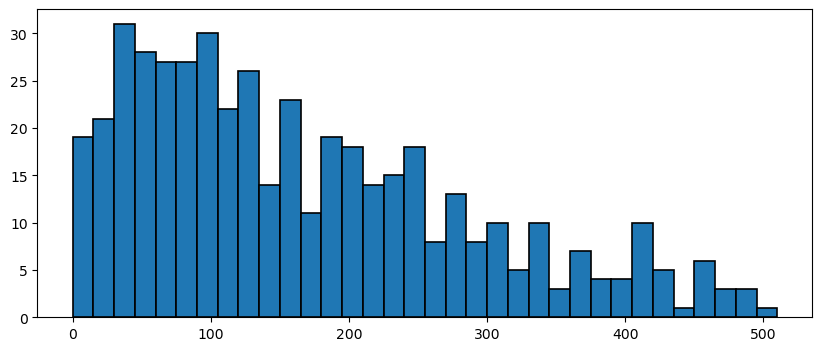

In [152]:
plot_timesteps(res, 500) # all default params except num_retailers = 25

{'mean': 167.9935064935065, 'median': 145.0}

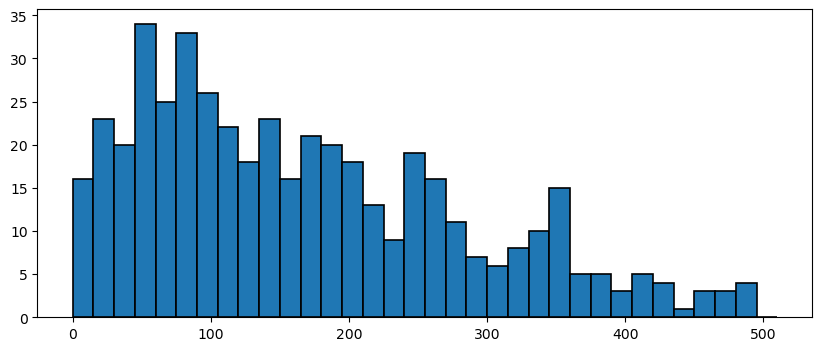

In [148]:
plot_timesteps(res, 500) # all default params